In [ ]:
# !pip install tensorflow

In [1]:
# 딥러닝 지원 모듈 준비

import tensorflow as tf
# import keras
from tensorflow import keras as tf_keras

In [2]:
# 데이터 준비
# fashion_mnist_dataset = tf_keras.datasets.fashion_mnist.load_data()

(X_train, y_train), (X_test, y_test) = tf_keras.datasets.fashion_mnist.load_data()

print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(60000, 28, 28) (60000,) (10000, 28, 28) (10000,)


9


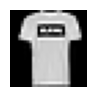

In [4]:
# 데이터 확인

import matplotlib.pyplot as plt

print(y_train[0])
plt.figure(figsize=(1, 1))
plt.imshow(X_train[1], cmap='gray')
plt.axis('off')
plt.show()

In [5]:
# 데이터 전처리

idx2label = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat", "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot" ]

# X_train = X_train.reshape(-1, 28*28)
# X_test = X_test.reshape(-1, 28*28)

X_train_scaled = X_train / 255
X_test_scaled = X_test / 255

print(X_train.max(), X_test.max(), X_train_scaled.max(), X_test_scaled.max())

255 255 1.0 1.0


In [6]:
# 모델 구조 설계

model = tf_keras.models.Sequential([
    tf_keras.layers.Input(shape=(28,28,1)),
    tf_keras.layers.Conv2D(32, kernel_size=(3,3), strides=(1,1), padding='same', activation='relu'),
    tf_keras.layers.MaxPool2D(pool_size=(2,2)),
    tf_keras.layers.Conv2D(64, kernel_size=(3,3), strides=(1,1), padding='same', activation='relu'),
    tf_keras.layers.MaxPool2D(pool_size=(2,2)),
    tf_keras.layers.Flatten(), # 출력을 1차원으로 변환
    tf_keras.layers.Dropout(0.5),
    tf_keras.layers.Dense(128, activation='relu'),
    tf_keras.layers.Dense(10, activation='softmax')
])

In [7]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 421,642 (1.61 MB)

 Trainable params: 421,642 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
# 모델 학습 설계

model.compile(loss="sparse_categorical_crossentropy",
              optimizer="adam",
              metrics=['accuracy'])

In [9]:
# 모델 훈련

# history = model.fit(X_train, y_train, batch_size=32, epochs=20, validation_split=0.2)
history = model.fit(X_train_scaled, y_train, batch_size=32, epochs=20, validation_split=0.2) # 테스트용 20%

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.8284 - loss: 0.4699 - val_accuracy: 0.8768 - val_loss: 0.3382
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.8822 - loss: 0.3261 - val_accuracy: 0.8972 - val_loss: 0.2841
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - accuracy: 0.8959 - loss: 0.2833 - val_accuracy: 0.9104 - val_loss: 0.2451
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 19s 13ms/step - accuracy: 0.9068 - loss: 0.2535 - val_accuracy: 0.9135 - val_loss: 0.2363
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 19s 13ms/step - accuracy: 0.9127 - loss: 0.2320 - val_accuracy: 0.9136 - val_loss: 0.2329
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 19s 13ms/step - accuracy: 0.9195 - loss: 0.2133 - val_accuracy: 0.9167 - val_loss: 0.2198
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 19s 13ms/step - accuracy: 0.9250 - loss: 0.2001 - val_accuracy: 0.9146 - val_loss: 0.2315
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 19s 13ms/step - accuracy: 0.9287 -